In [26]:
import spacy 

nlp = spacy.load("ru_core_news_lg")

In [27]:
import pandas as pd

df = pd.read_csv("sleep_intents_seed.csv")
print(df.shape)
df.head()

(798, 2)


,text,intent
0,не могу уснуть уже почти час,insomnia_now
1,лежу в кровати и никак не засыпаю,insomnia_now
2,"сон не приходит, хотя очень хочу спать",insomnia_now
3,проснулся ночью и не могу уснуть обратно,insomnia_now
4,"снова бессонница, что делать",insomnia_now


In [28]:
df.intent.value_counts()

intent
insomnia_now             133
sleep_duration_report    133
sleep_schedule_report    133
welcome                  133
other                    133
goodbye                  133
Name: count, dtype: int64

In [29]:
def preprocess(text):
    doc = nlp(text)

    filtered_tokens = []

    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return " ".join(filtered_tokens)

In [30]:
def preprocess_new(text):
    doc = nlp(text)

    filtered_tokens = []

    for token in doc:
        if token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return " ".join(filtered_tokens)

In [31]:
preprocess_new('не могу уснуть уже почти час')

'не мочь уснуть уже почти час'

In [32]:
target = {'insomnia_now': 0, 'sleep_duration_report': 1, 'sleep_schedule_report': 2, 'welcome': 3, 'other': 4, 'goodbye': 5}

df['intent_num'] = df.intent.map(target)

In [33]:
df.head()

,text,intent,intent_num
0,не могу уснуть уже почти час,insomnia_now,0
1,лежу в кровати и никак не засыпаю,insomnia_now,0
2,"сон не приходит, хотя очень хочу спать",insomnia_now,0
3,проснулся ночью и не могу уснуть обратно,insomnia_now,0
4,"снова бессонница, что делать",insomnia_now,0


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.text, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [35]:
print(X_train.shape)
X_train.head()

(638,)


574                открой настройки телефона, пожалуйста
477                           здравствуй! можно начинать
380    примерно в 01:20 отключился, а в 06:00 уже про...
662         сколько сейчас времени в лондоне на сегодня?
248                     за ночь вышло примерно 7.75 часа
Name: text, dtype: object

In [36]:
y_train.value_counts()

intent_num
3    107
2    107
4    106
1    106
0    106
5    106
Name: count, dtype: int64

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support
)

# ЭТО КОД С COUNTVECTORIZER

In [38]:
clf_NB1 = Pipeline([
    ('vectorizer_bow', CountVectorizer()),
    ('Multi NV', MultinomialNB()),
])

clf_NB1.fit(X_train, y_train)

y_pred = clf_NB1.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [39]:
clf_NB2 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,2))),
    ('Multi NV', MultinomialNB()),
])

clf_NB2.fit(X_train, y_train)

y_pred = clf_NB2.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [40]:
clf_NB3 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,3))),
    ('Multi NV', MultinomialNB()),
])

clf_NB3.fit(X_train, y_train)

y_pred = clf_NB3.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [41]:
clf_KNE1 = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


clf_KNE1.fit(X_train, y_train)

y_pred = clf_KNE1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.79      1.00      0.88        26
           4       1.00      0.78      0.88        27
           5       0.93      0.93      0.93        27

    accuracy                           0.94       160
   macro avg       0.95      0.94      0.94       160
weighted avg       0.95      0.94      0.94       160



In [42]:
clf_KNE2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


clf_KNE2.fit(X_train, y_train)

y_pred = clf_KNE2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.70      0.83        27
           1       1.00      0.96      0.98        27
           2       1.00      0.92      0.96        26
           3       0.52      1.00      0.68        26
           4       1.00      0.70      0.83        27
           5       0.91      0.74      0.82        27

    accuracy                           0.84       160
   macro avg       0.90      0.84      0.85       160
weighted avg       0.91      0.84      0.85       160



In [43]:
clf_KNE3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


clf_KNE3.fit(X_train, y_train)

y_pred = clf_KNE3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.41      0.58        27
           1       1.00      0.96      0.98        27
           2       1.00      0.23      0.38        26
           3       0.28      1.00      0.44        26
           4       1.00      0.33      0.50        27
           5       0.94      0.56      0.70        27

    accuracy                           0.58       160
   macro avg       0.87      0.58      0.60       160
weighted avg       0.87      0.58      0.60       160



In [44]:
clf_KNC1 = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


clf_KNC1.fit(X_train, y_train)

y_pred = clf_KNC1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.96      0.98        27
           5       1.00      1.00      1.00        27

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [45]:
clf_KNC2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


clf_KNC2.fit(X_train, y_train)

y_pred = clf_KNC2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.81      0.90        27
           5       0.87      1.00      0.93        27

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



In [46]:
clf_KNC3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


clf_KNC3.fit(X_train, y_train)

y_pred = clf_KNC3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.81      0.90        27
           5       0.87      1.00      0.93        27

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



In [47]:
clf_RF1 = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', RandomForestClassifier())
])


clf_RF1.fit(X_train, y_train)

y_pred = clf_RF1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.87      1.00      0.93        26
           4       1.00      0.93      0.96        27
           5       0.96      0.89      0.92        27

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



In [48]:
clf_RF2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2))),
    ('rf', RandomForestClassifier())
])


clf_RF2.fit(X_train, y_train)

y_pred = clf_RF2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.84      1.00      0.91        26
           4       1.00      0.89      0.94        27
           5       0.96      0.89      0.92        27

    accuracy                           0.96       160
   macro avg       0.97      0.96      0.96       160
weighted avg       0.97      0.96      0.96       160



In [49]:
clf_RF3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', RandomForestClassifier())
])


clf_RF3.fit(X_train, y_train)

y_pred = clf_RF3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.84      1.00      0.91        26
           4       1.00      0.85      0.92        27
           5       0.92      0.89      0.91        27

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



,model,accuracy,macro_f1,weighted_f1
0,clf_NB2,0.9722,0.9727,0.9727
1,clf_NB3,0.9722,0.9727,0.9727
2,clf_NB1,0.9583,0.9581,0.9581
3,clf_KNC1,0.9583,0.9581,0.9581
4,clf_KNC2,0.9444,0.9435,0.9435
5,clf_KNC3,0.9444,0.9435,0.9435
6,clf_RF1,0.9306,0.9289,0.9289
7,clf_RF2,0.9028,0.9008,0.9008
8,clf_RF3,0.8889,0.8857,0.8857
9,clf_KNE1,0.7222,0.6790,0.6790


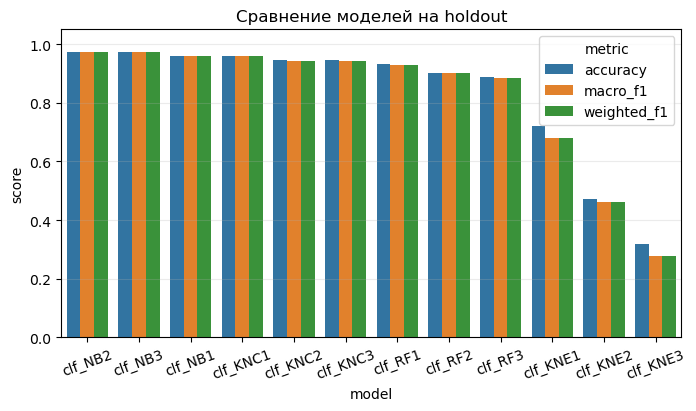

Лучшая модель: clf_NB2

                       precision    recall  f1-score   support

         insomnia_now     1.0000    0.9167    0.9565        12
sleep_duration_report     1.0000    1.0000    1.0000        12
sleep_schedule_report     0.8571    1.0000    0.9231        12
              welcome     1.0000    1.0000    1.0000        12
                other     1.0000    0.9167    0.9565        12
              goodbye     1.0000    1.0000    1.0000        12

             accuracy                         0.9722        72
            macro avg     0.9762    0.9722    0.9727        72
         weighted avg     0.9762    0.9722    0.9727        72



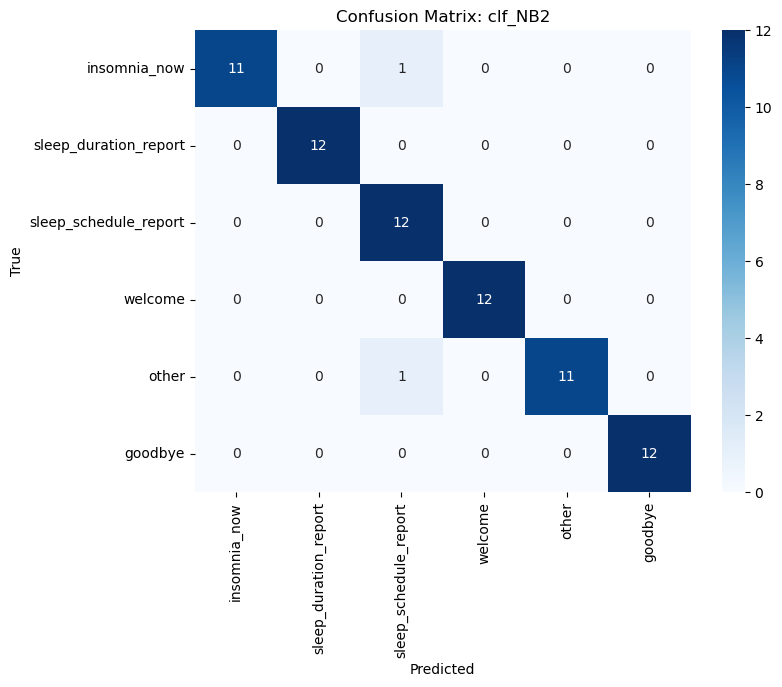

Ошибок: 2 из 72


,text,intent,pred_intent
0,проснулся среди ночи и больше не уснул,insomnia_now,sleep_schedule_report
1,подскажи рецепт омлета,other,sleep_schedule_report


,intent,precision,recall,f1,support
1,sleep_duration_report,1.0000,1.0000,1.0000,12
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,1.0000,1.0000,1.0000,12
0,insomnia_now,1.0000,0.9167,0.9565,12
4,other,1.0000,0.9167,0.9565,12
2,sleep_schedule_report,0.8571,1.0000,0.9231,12


In [50]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_NB1": clf_NB1,
    "clf_NB2": clf_NB2,
    "clf_NB3": clf_NB3,
    "clf_KNE1": clf_KNE1,
    "clf_KNE2": clf_KNE2,
    "clf_KNE3": clf_KNE3,
    "clf_KNC1": clf_KNC1,
    "clf_KNC2": clf_KNC2,
    "clf_KNC3": clf_KNC3,
    "clf_RF1": clf_RF1,
    "clf_RF2": clf_RF2,
    "clf_RF3": clf_RF3,
}
# Пример (раскомментируй, если есть):
# models = {
#     "nb_bow": clf_nb,
#     "lr_tfidf": clf_lr,
#     "svm_tfidf": clf_svm,
# }
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# ТУТ МОДЕЛИ ПОСЛЕ ЛЕММАТИЗАЦИИ

In [51]:
df['preprocessed_text'] = df.text.apply(preprocess)

In [52]:
df.head()

,text,intent,intent_num,preprocessed_text
0,не могу уснуть уже почти час,insomnia_now,0,уснуть час
1,лежу в кровати и никак не засыпаю,insomnia_now,0,лежать кровать засыпать
2,"сон не приходит, хотя очень хочу спать",insomnia_now,0,сон приходить спать
3,проснулся ночью и не могу уснуть обратно,insomnia_now,0,проснуться ночь уснуть обратно
4,"снова бессонница, что делать",insomnia_now,0,бессонница делать


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_text, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [54]:
pclf_NB1 = Pipeline([
    ('vectorizer_bow', CountVectorizer()),
    ('Multi NV', MultinomialNB()),
])

pclf_NB1.fit(X_train, y_train)

y_pred = pclf_NB1.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.96      1.00      0.98        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [55]:
pclf_NB2 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,2))),
    ('Multi NV', MultinomialNB()),
])

pclf_NB2.fit(X_train, y_train)

y_pred = pclf_NB2.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.96      1.00      0.98        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [56]:
pclf_NB3 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,3))),
    ('Multi NV', MultinomialNB()),
])

pclf_NB3.fit(X_train, y_train)

y_pred = pclf_NB3.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.96      1.00      0.98        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [57]:
pclf_KNE1 = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclf_KNE1.fit(X_train, y_train)

y_pred = pclf_KNE1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.59      0.74        27
           5       0.61      1.00      0.76        27

    accuracy                           0.89       160
   macro avg       0.94      0.90      0.90       160
weighted avg       0.93      0.89      0.90       160



In [58]:
pclf_KNE2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclf_KNE2.fit(X_train, y_train)

y_pred = pclf_KNE2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.30      0.46        27
           1       1.00      1.00      1.00        27
           2       1.00      0.62      0.76        26
           3       0.88      0.88      0.88        26
           4       1.00      0.63      0.77        27
           5       0.41      1.00      0.58        27

    accuracy                           0.74       160
   macro avg       0.88      0.74      0.74       160
weighted avg       0.88      0.74      0.74       160



In [59]:
pclf_KNE3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclf_KNE3.fit(X_train, y_train)

y_pred = pclf_KNE3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.07      0.14        27
           1       1.00      0.96      0.98        27
           2       1.00      0.08      0.14        26
           3       0.86      0.73      0.79        26
           4       1.00      0.44      0.62        27
           5       0.28      1.00      0.44        27

    accuracy                           0.55       160
   macro avg       0.86      0.55      0.52       160
weighted avg       0.86      0.55      0.52       160



In [60]:
pclf_KNC1 = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclf_KNC1.fit(X_train, y_train)

y_pred = pclf_KNC1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.96      1.00      0.98        26
           4       1.00      0.81      0.90        27
           5       0.87      1.00      0.93        27

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



In [61]:
pclf_KNC2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclf_KNC2.fit(X_train, y_train)

y_pred = pclf_KNC2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.96      1.00      0.98        26
           4       1.00      0.81      0.90        27
           5       0.87      1.00      0.93        27

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



In [62]:
pclf_KNC3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclf_KNC3.fit(X_train, y_train)

y_pred = pclf_KNC3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.96      1.00      0.98        26
           4       1.00      0.81      0.90        27
           5       0.87      1.00      0.93        27

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



In [63]:
pclf_RF1 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', RandomForestClassifier())
])


pclf_RF1.fit(X_train, y_train)

y_pred = pclf_RF1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      0.96      0.98        26
           4       1.00      0.93      0.96        27
           5       0.90      1.00      0.95        27

    accuracy                           0.98       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.98      0.98       160



In [64]:
pclf_RF2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', RandomForestClassifier())
])


pclf_RF2.fit(X_train, y_train)

y_pred = pclf_RF2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      0.96      0.98        26
           4       1.00      0.93      0.96        27
           5       0.90      1.00      0.95        27

    accuracy                           0.98       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.98      0.98       160



In [65]:
pclf_RF3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', RandomForestClassifier())
])


pclf_RF3.fit(X_train, y_train)

y_pred = pclf_RF3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      0.96      0.98        26
           4       1.00      0.93      0.96        27
           5       0.90      1.00      0.95        27

    accuracy                           0.98       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.98      0.98       160



,model,accuracy,macro_f1,weighted_f1
0,pclf_KNC2,0.7083,0.7048,0.7048
1,pclf_KNC3,0.6944,0.6953,0.6953
2,pclf_NB2,0.6944,0.6813,0.6813
3,pclf_NB3,0.6944,0.6813,0.6813
4,pclf_KNC1,0.6806,0.6789,0.6789
5,pclf_NB1,0.6806,0.6574,0.6574
6,pclf_RF1,0.5556,0.5230,0.5230
7,pclf_RF2,0.5278,0.4878,0.4878
8,pclf_RF3,0.5278,0.4878,0.4878
9,pclf_KNE1,0.3889,0.3557,0.3557


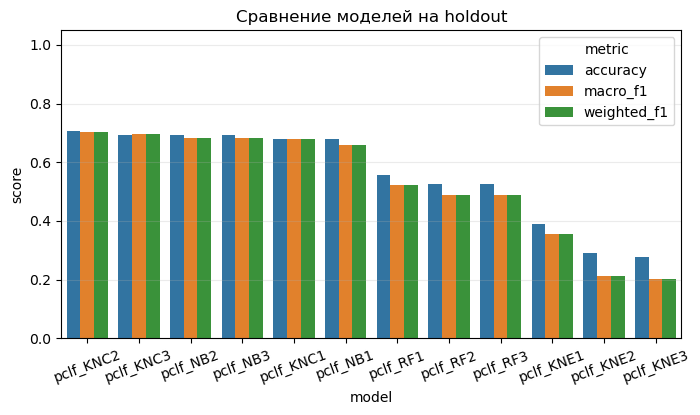

Лучшая модель: pclf_KNC2

                       precision    recall  f1-score   support

         insomnia_now     0.8333    0.4167    0.5556        12
sleep_duration_report     0.3810    0.6667    0.4848        12
sleep_schedule_report     0.8571    1.0000    0.9231        12
              welcome     0.9231    1.0000    0.9600        12
                other     0.8333    0.4167    0.5556        12
              goodbye     0.7500    0.7500    0.7500        12

             accuracy                         0.7083        72
            macro avg     0.7630    0.7083    0.7048        72
         weighted avg     0.7630    0.7083    0.7048        72



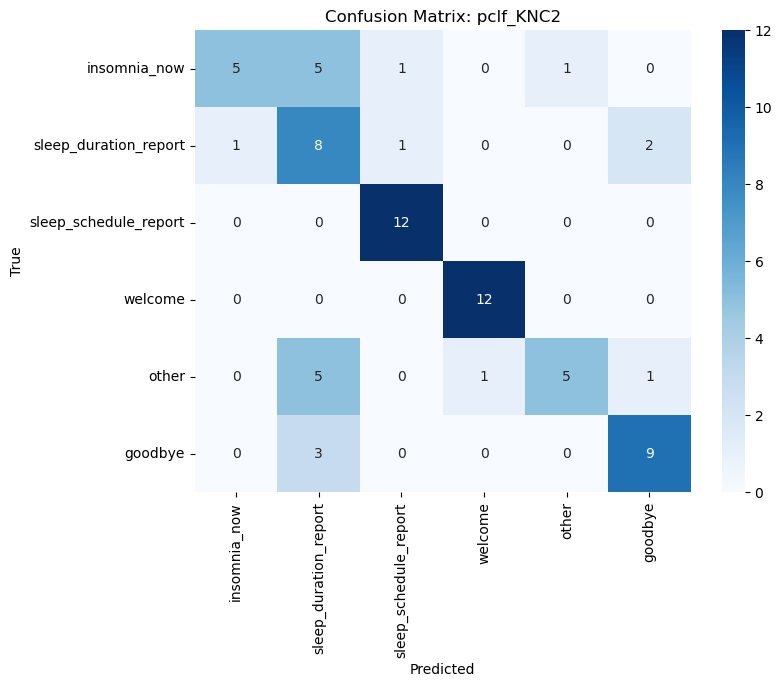

Ошибок: 21 из 72


,text,intent,pred_intent
0,проснулся среди ночи и больше не уснул,insomnia_now,sleep_duration_report
1,"помоги, пожалуйста, я никак не засыпаю",insomnia_now,sleep_duration_report
2,"время позднее, а я все еще бодрствую",insomnia_now,other
3,после тяжелого дня не получается отключиться,insomnia_now,sleep_schedule_report
4,"в кровати уже давно, а сна нет совсем",insomnia_now,sleep_duration_report
5,"опять бессонная ночь, не могу уснуть",insomnia_now,sleep_duration_report
6,не засыпаю уже второй час подряд,insomnia_now,sleep_duration_report
7,сегодня набралось только 4 часа сна,sleep_duration_report,goodbye
8,мой сон длился около 8 часов,sleep_duration_report,insomnia_now
9,по трекеру получилось 5 часов 20 минут,sleep_duration_report,sleep_schedule_report


,intent,precision,recall,f1,support
3,welcome,0.9231,1.0000,0.9600,12
2,sleep_schedule_report,0.8571,1.0000,0.9231,12
5,goodbye,0.7500,0.7500,0.7500,12
0,insomnia_now,0.8333,0.4167,0.5556,12
4,other,0.8333,0.4167,0.5556,12
1,sleep_duration_report,0.3810,0.6667,0.4848,12


In [66]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "pclf_NB1": pclf_NB1,
    "pclf_NB2": pclf_NB2,
    "pclf_NB3": pclf_NB3,
    "pclf_KNE1": pclf_KNE1,
    "pclf_KNE2": pclf_KNE2,
    "pclf_KNE3": pclf_KNE3,
    "pclf_KNC1": pclf_KNC1,
    "pclf_KNC2": pclf_KNC2,
    "pclf_KNC3": pclf_KNC3,
    "pclf_RF1": pclf_RF1,
    "pclf_RF2": pclf_RF2,
    "pclf_RF3": pclf_RF3,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


,model,accuracy,macro_f1,weighted_f1
0,clf_NB2,0.9722,0.9727,0.9727
1,clf_NB3,0.9722,0.9727,0.9727
2,clf_NB1,0.9583,0.9581,0.9581
3,clf_KNC1,0.9583,0.9581,0.9581
4,clf_KNC2,0.9444,0.9435,0.9435
5,clf_KNC3,0.9444,0.9435,0.9435
6,clf_RF2,0.9306,0.9306,0.9306
7,clf_RF3,0.9167,0.9170,0.9170
8,clf_RF1,0.9167,0.9168,0.9168
9,pclf_KNC2,0.7083,0.7048,0.7048


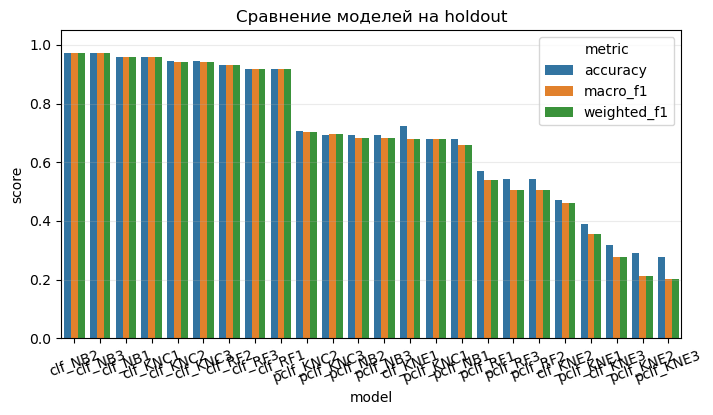

Лучшая модель: clf_NB2

                       precision    recall  f1-score   support

         insomnia_now     1.0000    0.9167    0.9565        12
sleep_duration_report     1.0000    1.0000    1.0000        12
sleep_schedule_report     0.8571    1.0000    0.9231        12
              welcome     1.0000    1.0000    1.0000        12
                other     1.0000    0.9167    0.9565        12
              goodbye     1.0000    1.0000    1.0000        12

             accuracy                         0.9722        72
            macro avg     0.9762    0.9722    0.9727        72
         weighted avg     0.9762    0.9722    0.9727        72



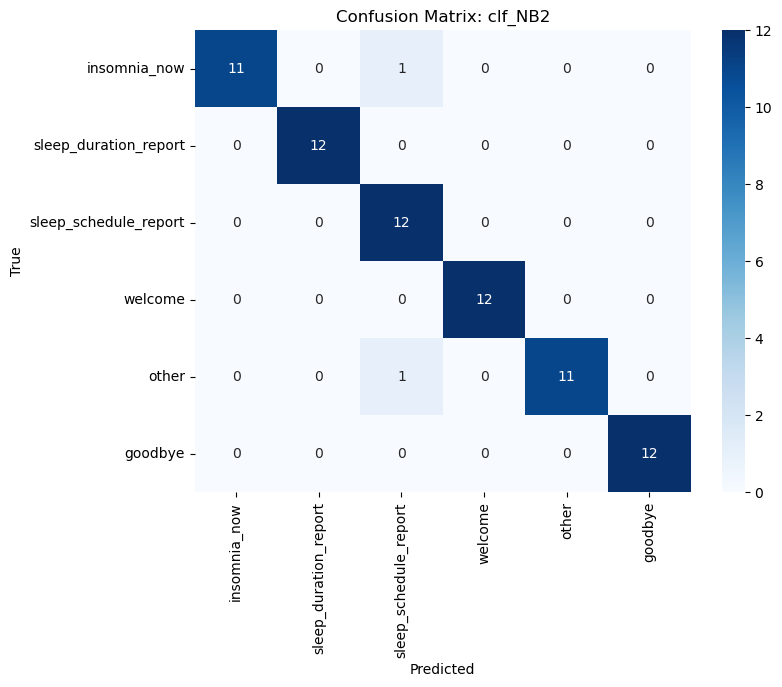

Ошибок: 2 из 72


,text,intent,pred_intent
0,проснулся среди ночи и больше не уснул,insomnia_now,sleep_schedule_report
1,подскажи рецепт омлета,other,sleep_schedule_report


,intent,precision,recall,f1,support
1,sleep_duration_report,1.0000,1.0000,1.0000,12
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,1.0000,1.0000,1.0000,12
0,insomnia_now,1.0000,0.9167,0.9565,12
4,other,1.0000,0.9167,0.9565,12
2,sleep_schedule_report,0.8571,1.0000,0.9231,12


In [95]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_NB1": clf_NB1,
    "clf_NB2": clf_NB2,
    "clf_NB3": clf_NB3,
    "clf_KNE1": clf_KNE1,
    "clf_KNE2": clf_KNE2,
    "clf_KNE3": clf_KNE3,
    "clf_KNC1": clf_KNC1,
    "clf_KNC2": clf_KNC2,
    "clf_KNC3": clf_KNC3,
    "clf_RF1": clf_RF1,
    "clf_RF2": clf_RF2,
    "clf_RF3": clf_RF3,
    "pclf_NB1": pclf_NB1,
    "pclf_NB2": pclf_NB2,
    "pclf_NB3": pclf_NB3,
    "pclf_KNE1": pclf_KNE1,
    "pclf_KNE2": pclf_KNE2,
    "pclf_KNE3": pclf_KNE3,
    "pclf_KNC1": pclf_KNC1,
    "pclf_KNC2": pclf_KNC2,
    "pclf_KNC3": pclf_KNC3,
    "pclf_RF1": pclf_RF1,
    "pclf_RF2": pclf_RF2,
    "pclf_RF3": pclf_RF3,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# ЭТО КОД С COUTVECTORIZER после Preprocess, но с stop словами

In [67]:
df['preprocessed_text_new'] = df.text.apply(preprocess_new)

In [68]:
df.head()

,text,intent,intent_num,preprocessed_text,preprocessed_text_new
0,не могу уснуть уже почти час,insomnia_now,0,уснуть час,не мочь уснуть уже почти час
1,лежу в кровати и никак не засыпаю,insomnia_now,0,лежать кровать засыпать,лежать в кровать и никак не засыпать
2,"сон не приходит, хотя очень хочу спать",insomnia_now,0,сон приходить спать,сон не приходить хотя очень хотеть спать
3,проснулся ночью и не могу уснуть обратно,insomnia_now,0,проснуться ночь уснуть обратно,проснуться ночь и не мочь уснуть обратно
4,"снова бессонница, что делать",insomnia_now,0,бессонница делать,снова бессонница что делать


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_text_new, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [70]:
pclfn_NB1 = Pipeline([
    ('vectorizer_bow', CountVectorizer()),
    ('Multi NV', MultinomialNB()),
])

pclfn_NB1.fit(X_train, y_train)

y_pred = pclfn_NB1.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [71]:
pclfn_NB2 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,2))),
    ('Multi NV', MultinomialNB()),
])

pclfn_NB2.fit(X_train, y_train)

y_pred = pclfn_NB2.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [72]:
pclfn_NB3 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,3))),
    ('Multi NV', MultinomialNB()),
])

pclfn_NB3.fit(X_train, y_train)

y_pred = pclfn_NB3.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [73]:
pclfn_KNE1 = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclfn_KNE1.fit(X_train, y_train)

y_pred = pclfn_KNE1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.76      1.00      0.87        26
           4       1.00      0.74      0.85        27
           5       0.93      0.93      0.93        27

    accuracy                           0.94       160
   macro avg       0.95      0.94      0.94       160
weighted avg       0.95      0.94      0.94       160



In [74]:
pclfn_KNE2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclfn_KNE2.fit(X_train, y_train)

y_pred = pclfn_KNE2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.81      0.90        27
           1       1.00      1.00      1.00        27
           2       1.00      0.92      0.96        26
           3       0.54      1.00      0.70        26
           4       1.00      0.63      0.77        27
           5       0.91      0.74      0.82        27

    accuracy                           0.85       160
   macro avg       0.91      0.85      0.86       160
weighted avg       0.91      0.85      0.86       160



In [75]:
pclfn_KNE3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclfn_KNE3.fit(X_train, y_train)

y_pred = pclfn_KNE3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.37      0.54        27
           1       1.00      1.00      1.00        27
           2       1.00      0.23      0.38        26
           3       0.28      1.00      0.44        26
           4       1.00      0.33      0.50        27
           5       0.94      0.56      0.70        27

    accuracy                           0.58       160
   macro avg       0.87      0.58      0.59       160
weighted avg       0.87      0.58      0.59       160



In [76]:
pclfn_KNC1 = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclfn_KNC1.fit(X_train, y_train)

y_pred = pclfn_KNC1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.96      0.98        27
           5       1.00      1.00      1.00        27

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [77]:
pclfn_KNC2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclfn_KNC2.fit(X_train, y_train)

y_pred = pclfn_KNC2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.81      0.90        27
           5       0.87      1.00      0.93        27

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



In [78]:
pclfn_KNC3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclfn_KNC3.fit(X_train, y_train)

y_pred = pclfn_KNC3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.81      0.90        27
           5       0.87      1.00      0.93        27

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



In [79]:
pclfn_RF1 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', RandomForestClassifier())
])


pclfn_RF1.fit(X_train, y_train)

y_pred = pclfn_RF1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.81      1.00      0.90        26
           4       1.00      0.89      0.94        27
           5       1.00      0.89      0.94        27

    accuracy                           0.96       160
   macro avg       0.97      0.96      0.96       160
weighted avg       0.97      0.96      0.96       160



In [80]:
pclfn_RF2 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', RandomForestClassifier())
])


pclfn_RF2.fit(X_train, y_train)

y_pred = pclfn_RF2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.81      1.00      0.90        26
           4       1.00      0.85      0.92        27
           5       0.96      0.89      0.92        27

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



In [81]:
pclfn_RF3 = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3))),
    ('rf', RandomForestClassifier())
])


pclfn_RF3.fit(X_train, y_train)

y_pred = pclfn_RF3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.81      1.00      0.90        26
           4       1.00      0.85      0.92        27
           5       0.96      0.89      0.92        27

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



,model,accuracy,macro_f1,weighted_f1
0,pclfn_NB3,0.8750,0.8731,0.8731
1,pclfn_NB1,0.8750,0.8730,0.8730
2,pclfn_NB2,0.8750,0.8730,0.8730
3,pclfn_KNC1,0.8472,0.8474,0.8474
4,pclfn_KNC2,0.8472,0.8447,0.8447
5,pclfn_KNC3,0.8333,0.8314,0.8314
6,pclfn_RF3,0.6944,0.6891,0.6891
7,pclfn_RF1,0.6806,0.6786,0.6786
8,pclfn_RF2,0.6667,0.6597,0.6597
9,pclfn_KNE1,0.4583,0.4354,0.4354


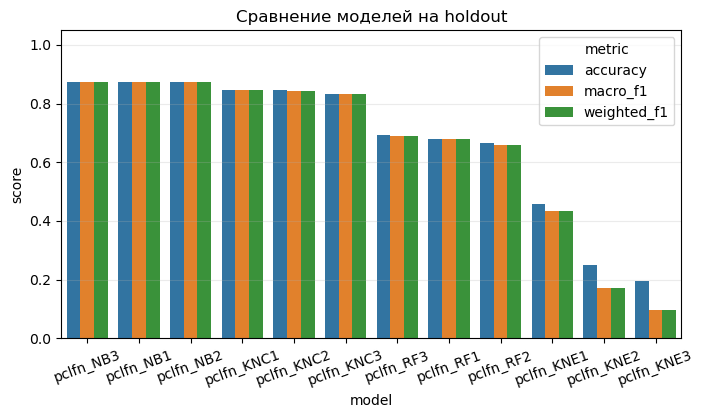

Лучшая модель: pclfn_NB3

                       precision    recall  f1-score   support

         insomnia_now     0.9091    0.8333    0.8696        12
sleep_duration_report     1.0000    0.8333    0.9091        12
sleep_schedule_report     0.6667    1.0000    0.8000        12
              welcome     1.0000    1.0000    1.0000        12
                other     1.0000    0.5833    0.7368        12
              goodbye     0.8571    1.0000    0.9231        12

             accuracy                         0.8750        72
            macro avg     0.9055    0.8750    0.8731        72
         weighted avg     0.9055    0.8750    0.8731        72



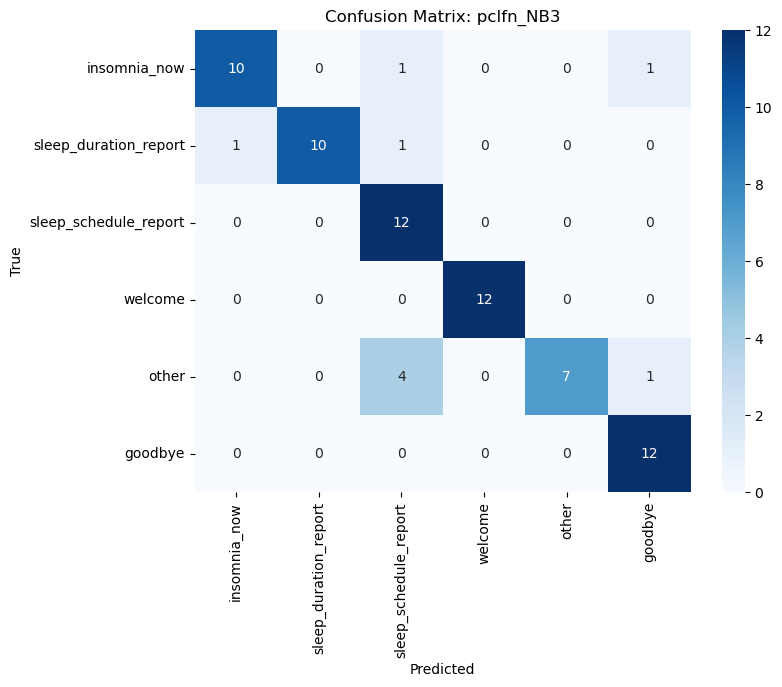

Ошибок: 9 из 72


,text,intent,pred_intent
0,"время позднее, а я все еще бодрствую",insomnia_now,goodbye
1,"в кровати уже давно, а сна нет совсем",insomnia_now,sleep_schedule_report
2,по трекеру получилось 5 часов 20 минут,sleep_duration_report,sleep_schedule_report
3,этой ночью проспал почти 9 часов,sleep_duration_report,insomnia_now
4,покажи погоду на сегодня,other,goodbye
5,переведи фразу good morning,other,sleep_schedule_report
6,расскажи короткую шутку,other,sleep_schedule_report
7,найди ближайшую аптеку,other,sleep_schedule_report
8,подскажи рецепт омлета,other,sleep_schedule_report


,intent,precision,recall,f1,support
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,0.8571,1.0000,0.9231,12
1,sleep_duration_report,1.0000,0.8333,0.9091,12
0,insomnia_now,0.9091,0.8333,0.8696,12
2,sleep_schedule_report,0.6667,1.0000,0.8000,12
4,other,1.0000,0.5833,0.7368,12


In [82]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "pclfn_NB1": pclfn_NB1,
    "pclfn_NB2": pclfn_NB2,
    "pclfn_NB3": pclfn_NB3,
    "pclfn_KNE1": pclfn_KNE1,
    "pclfn_KNE2": pclfn_KNE2,
    "pclfn_KNE3": pclfn_KNE3,
    "pclfn_KNC1": pclfn_KNC1,
    "pclfn_KNC2": pclfn_KNC2,
    "pclfn_KNC3": pclfn_KNC3,
    "pclfn_RF1": pclfn_RF1,
    "pclfn_RF2": pclfn_RF2,
    "pclfn_RF3": pclfn_RF3,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


,model,accuracy,macro_f1,weighted_f1
0,clf_NB2,0.9722,0.9727,0.9727
1,clf_NB3,0.9722,0.9727,0.9727
2,clf_NB1,0.9583,0.9581,0.9581
3,clf_KNC1,0.9583,0.9581,0.9581
4,clf_KNC2,0.9444,0.9435,0.9435
5,clf_KNC3,0.9444,0.9435,0.9435
6,clf_RF1,0.9306,0.9289,0.9289
7,clf_RF2,0.9028,0.9008,0.9008
8,clf_RF3,0.8889,0.8857,0.8857
9,pclfn_NB3,0.8750,0.8731,0.8731


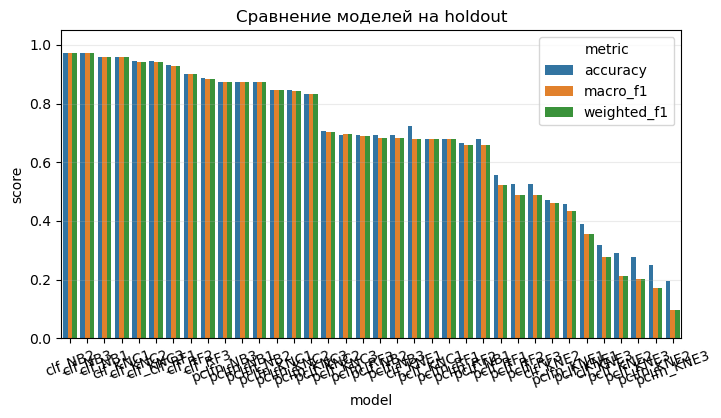

Лучшая модель: clf_NB2

                       precision    recall  f1-score   support

         insomnia_now     1.0000    0.9167    0.9565        12
sleep_duration_report     1.0000    1.0000    1.0000        12
sleep_schedule_report     0.8571    1.0000    0.9231        12
              welcome     1.0000    1.0000    1.0000        12
                other     1.0000    0.9167    0.9565        12
              goodbye     1.0000    1.0000    1.0000        12

             accuracy                         0.9722        72
            macro avg     0.9762    0.9722    0.9727        72
         weighted avg     0.9762    0.9722    0.9727        72



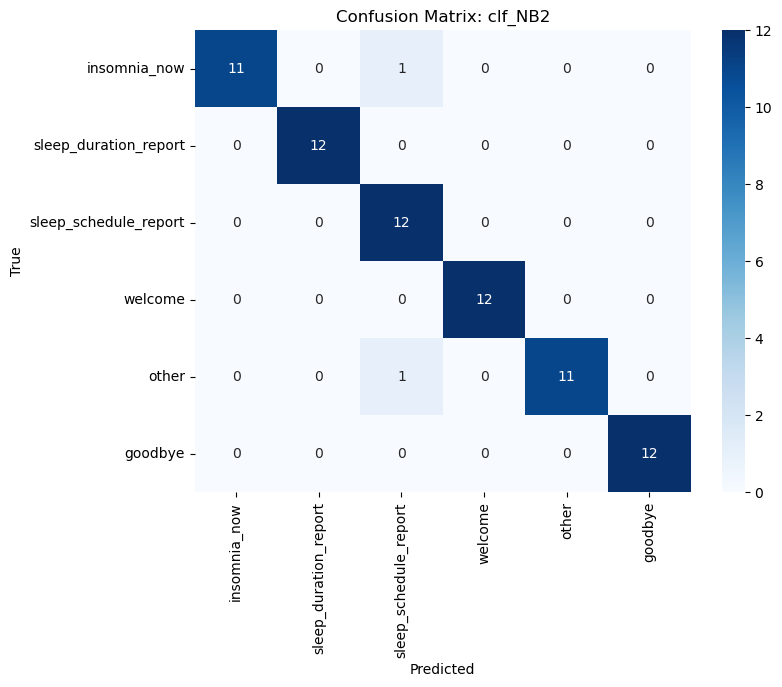

Ошибок: 2 из 72


,text,intent,pred_intent
0,проснулся среди ночи и больше не уснул,insomnia_now,sleep_schedule_report
1,подскажи рецепт омлета,other,sleep_schedule_report


,intent,precision,recall,f1,support
1,sleep_duration_report,1.0000,1.0000,1.0000,12
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,1.0000,1.0000,1.0000,12
0,insomnia_now,1.0000,0.9167,0.9565,12
4,other,1.0000,0.9167,0.9565,12
2,sleep_schedule_report,0.8571,1.0000,0.9231,12


In [110]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_NB1": clf_NB1,
    "clf_NB2": clf_NB2,
    "clf_NB3": clf_NB3,
    "clf_KNE1": clf_KNE1,
    "clf_KNE2": clf_KNE2,
    "clf_KNE3": clf_KNE3,
    "clf_KNC1": clf_KNC1,
    "clf_KNC2": clf_KNC2,
    "clf_KNC3": clf_KNC3,
    "clf_RF1": clf_RF1,
    "clf_RF2": clf_RF2,
    "clf_RF3": clf_RF3,
    "pclf_NB1": pclf_NB1,
    "pclf_NB2": pclf_NB2,
    "pclf_NB3": pclf_NB3,
    "pclf_KNE1": pclf_KNE1,
    "pclf_KNE2": pclf_KNE2,
    "pclf_KNE3": pclf_KNE3,
    "pclf_KNC1": pclf_KNC1,
    "pclf_KNC2": pclf_KNC2,
    "pclf_KNC3": pclf_KNC3,
    "pclf_RF1": pclf_RF1,
    "pclf_RF2": pclf_RF2,
    "pclf_RF3": pclf_RF3,
    "pclfn_NB1": pclfn_NB1,
    "pclfn_NB2": pclfn_NB2,
    "pclfn_NB3": pclfn_NB3,
    "pclfn_KNE1": pclfn_KNE1,
    "pclfn_KNE2": pclfn_KNE2,
    "pclfn_KNE3": pclfn_KNE3,
    "pclfn_KNC1": pclfn_KNC1,
    "pclfn_KNC2": pclfn_KNC2,
    "pclfn_KNC3": pclfn_KNC3,
    "pclfn_RF1": pclfn_RF1,
    "pclfn_RF2": pclfn_RF2,
    "pclfn_RF3": pclfn_RF3,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# ЭТО КОД С TFIDVECTORIZER

<h1>Тут будет текст до preprocess</h1>

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    df.text, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [84]:
clf_NB1T = Pipeline([
    ('vectorizer_bow', TfidfVectorizer()),
    ('Multi NV', MultinomialNB()),
])

clf_NB1T.fit(X_train, y_train)

y_pred = clf_NB1T.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [85]:
clf_KNE1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


clf_KNE1T.fit(X_train, y_train)

y_pred = clf_KNE1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.93      1.00      0.96        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.89      0.94        27
           5       0.93      0.96      0.95        27

    accuracy                           0.97       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.97      0.97       160



In [86]:
clf_KNC1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


clf_KNC1T.fit(X_train, y_train)

y_pred = clf_KNC1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.93      0.96        27
           5       0.93      1.00      0.96        27

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [87]:
clf_RF1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', RandomForestClassifier())
])


clf_RF1T.fit(X_train, y_train)

y_pred = clf_RF1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.84      1.00      0.91        26
           4       1.00      0.89      0.94        27
           5       0.96      0.89      0.92        27

    accuracy                           0.96       160
   macro avg       0.97      0.96      0.96       160
weighted avg       0.97      0.96      0.96       160



,model,accuracy,macro_f1,weighted_f1
0,clf_NB1T,0.9722,0.9727,0.9727
1,clf_KNC1T,0.9583,0.9581,0.9581
2,clf_KNE1T,0.9167,0.9161,0.9161
3,clf_RF1T,0.8889,0.8856,0.8856


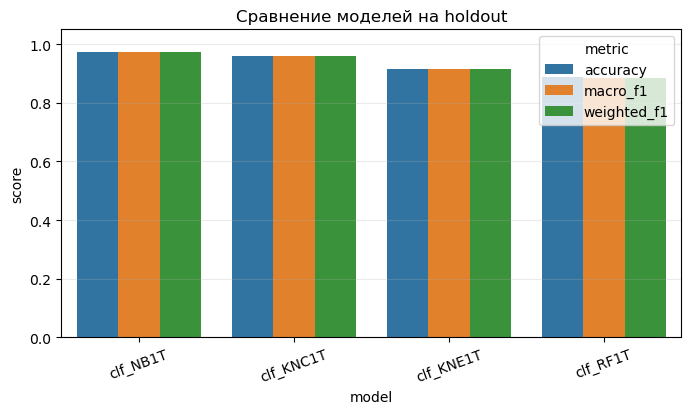

Лучшая модель: clf_NB1T

                       precision    recall  f1-score   support

         insomnia_now     1.0000    0.9167    0.9565        12
sleep_duration_report     1.0000    1.0000    1.0000        12
sleep_schedule_report     0.8571    1.0000    0.9231        12
              welcome     1.0000    1.0000    1.0000        12
                other     1.0000    0.9167    0.9565        12
              goodbye     1.0000    1.0000    1.0000        12

             accuracy                         0.9722        72
            macro avg     0.9762    0.9722    0.9727        72
         weighted avg     0.9762    0.9722    0.9727        72



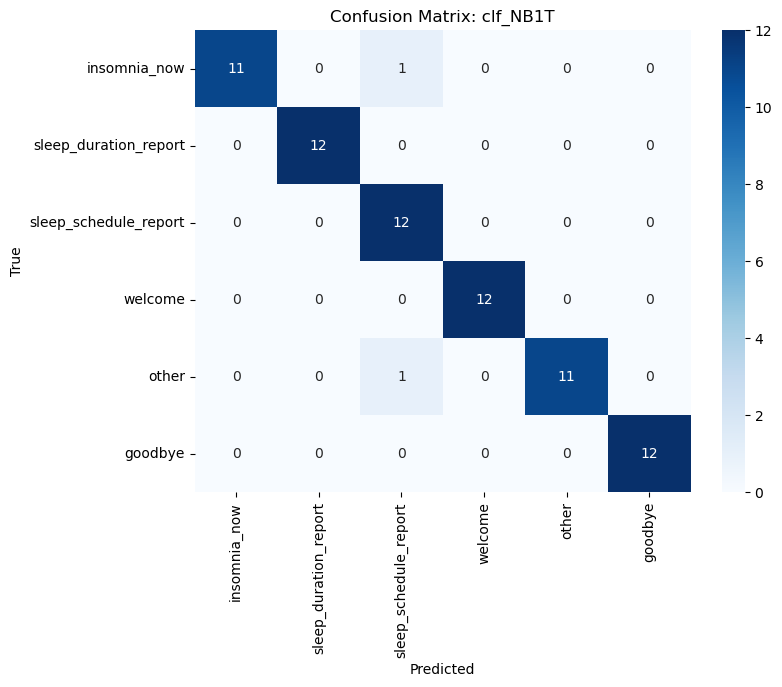

Ошибок: 2 из 72


,text,intent,pred_intent
0,проснулся среди ночи и больше не уснул,insomnia_now,sleep_schedule_report
1,подскажи рецепт омлета,other,sleep_schedule_report


,intent,precision,recall,f1,support
1,sleep_duration_report,1.0000,1.0000,1.0000,12
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,1.0000,1.0000,1.0000,12
0,insomnia_now,1.0000,0.9167,0.9565,12
4,other,1.0000,0.9167,0.9565,12
2,sleep_schedule_report,0.8571,1.0000,0.9231,12


In [111]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_NB1T": clf_NB1T,
    "clf_KNE1T": clf_KNE1T,
    "clf_KNC1T": clf_KNC1T,
    "clf_RF1T": clf_RF1T,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# ЭТО КОД С TFIDVECTORIZER c Preprocess

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_text, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [92]:
pclf_NB1T = Pipeline([
    ('vectorizer_bow', TfidfVectorizer()),
    ('Multi NV', MultinomialNB()),
])

pclf_NB1T.fit(X_train, y_train)

y_pred = pclf_NB1T.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.96      1.00      0.98        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [ ]:
pclf_NB2T = Pipeline([
    ('vectorizer_bow', TfidfVectorizer(ngram_range=(1, 2))),
    ('Multi NV', MultinomialNB()),
])

pclf_NB2T.fit(X_train, y_train)

y_pred = pclf_NB2T.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
pclf_NB3T = Pipeline([
    ('vectorizer_bow', TfidfVectorizer(ngram_range=(1, 3))),
    ('Multi NV', MultinomialNB()),
])

pclf_NB3T.fit(X_train, y_train)

y_pred = pclf_NB3T.predict(X_test)

print(classification_report(y_test, y_pred))

In [93]:
pclf_KNE1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclf_KNE1T.fit(X_train, y_train)

y_pred = pclf_KNE1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        27
           1       0.96      1.00      0.98        27
           2       1.00      1.00      1.00        26
           3       0.96      1.00      0.98        26
           4       1.00      0.85      0.92        27
           5       0.87      1.00      0.93        27

    accuracy                           0.96       160
   macro avg       0.97      0.96      0.96       160
weighted avg       0.97      0.96      0.96       160



In [ ]:
pclf_KNE2T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclf_KNE2T.fit(X_train, y_train)

y_pred = pclf_KNE2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclf_KNE3T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclf_KNE3T.fit(X_train, y_train)

y_pred = pclf_KNE3T.predict(X_test)
print(classification_report(y_test, y_pred))

In [94]:
pclf_KNC1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclf_KNC1T.fit(X_train, y_train)

y_pred = pclf_KNC1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.96      1.00      0.98        27
           2       1.00      1.00      1.00        26
           3       0.96      1.00      0.98        26
           4       1.00      0.89      0.94        27
           5       0.93      1.00      0.96        27

    accuracy                           0.97       160
   macro avg       0.98      0.98      0.97       160
weighted avg       0.98      0.97      0.97       160



In [ ]:
pclf_KNC2T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclf_KNC2T.fit(X_train, y_train)

y_pred = pclf_KNC2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclf_KNC3T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclf_KNC3T.fit(X_train, y_train)

y_pred = pclf_KNC3T.predict(X_test)
print(classification_report(y_test, y_pred))

In [95]:
pclf_RF1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', RandomForestClassifier())
])


pclf_RF1T.fit(X_train, y_train)

y_pred = pclf_RF1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      0.96      0.98        26
           4       1.00      0.93      0.96        27
           5       0.90      1.00      0.95        27

    accuracy                           0.98       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.98      0.98       160



In [ ]:
pclf_RF2T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('rf', RandomForestClassifier())
])


pclf_RF2T.fit(X_train, y_train)

y_pred = pclf_RF2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclf_RF3T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
    ('rf', RandomForestClassifier())
])


pclf_RF3T.fit(X_train, y_train)

y_pred = pclf_RF3T.predict(X_test)
print(classification_report(y_test, y_pred))

,model,accuracy,macro_f1,weighted_f1
0,pclf_NB1T,0.6806,0.6582,0.6582
1,pclf_KNC1T,0.6667,0.6473,0.6473
2,pclf_KNE1T,0.6667,0.6423,0.6423
3,pclf_RF1T,0.5694,0.5497,0.5497


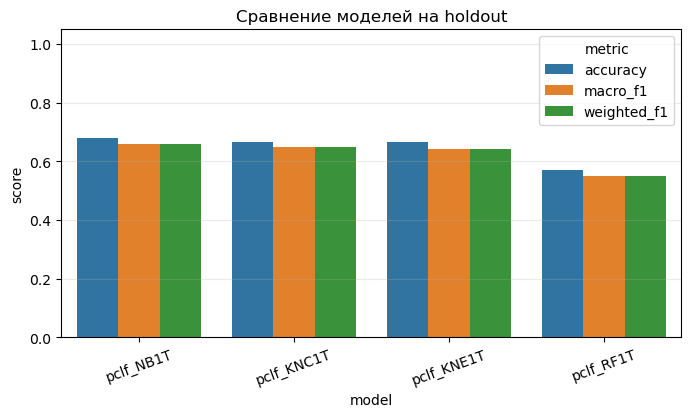

Лучшая модель: pclf_NB1T

                       precision    recall  f1-score   support

         insomnia_now     1.0000    0.1667    0.2857        12
sleep_duration_report     0.6667    0.6667    0.6667        12
sleep_schedule_report     0.4444    1.0000    0.6154        12
              welcome     1.0000    1.0000    1.0000        12
                other     0.8571    0.5000    0.6316        12
              goodbye     0.7500    0.7500    0.7500        12

             accuracy                         0.6806        72
            macro avg     0.7864    0.6806    0.6582        72
         weighted avg     0.7864    0.6806    0.6582        72



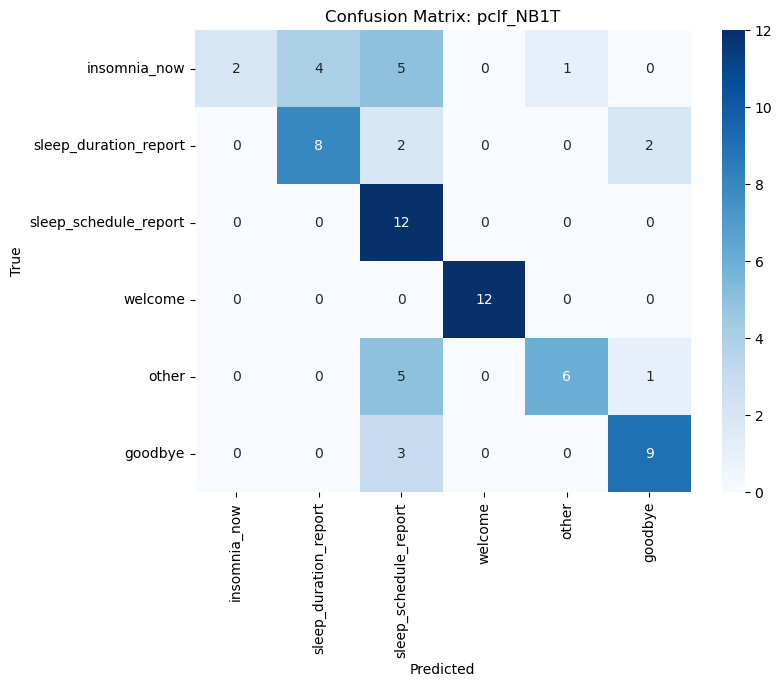

Ошибок: 23 из 72


,text,intent,pred_intent
0,сегодня снова не могу провалиться в сон,insomnia_now,sleep_duration_report
1,проснулся среди ночи и больше не уснул,insomnia_now,sleep_schedule_report
2,в голове шум и из-за этого не получается уснуть,insomnia_now,sleep_schedule_report
3,"помоги, пожалуйста, я никак не засыпаю",insomnia_now,sleep_schedule_report
4,"очень хочу спать, но сон вообще не приходит",insomnia_now,sleep_duration_report
5,"время позднее, а я все еще бодрствую",insomnia_now,other
6,после тяжелого дня не получается отключиться,insomnia_now,sleep_schedule_report
7,"в кровати уже давно, а сна нет совсем",insomnia_now,sleep_schedule_report
8,"опять бессонная ночь, не могу уснуть",insomnia_now,sleep_duration_report
9,не засыпаю уже второй час подряд,insomnia_now,sleep_duration_report


,intent,precision,recall,f1,support
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,0.7500,0.7500,0.7500,12
1,sleep_duration_report,0.6667,0.6667,0.6667,12
4,other,0.8571,0.5000,0.6316,12
2,sleep_schedule_report,0.4444,1.0000,0.6154,12
0,insomnia_now,1.0000,0.1667,0.2857,12


In [98]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "pclf_NB1T": pclf_NB1T,
    "pclf_NB2T": pclf_NB2T,
    "pclf_NB3T": pclf_NB3T,
    "pclf_KNE1T": pclf_KNE1T,
    "pclf_KNE2T": pclf_KNE2T,
    "pclf_KNE3T": pclf_KNE3T,
    "pclf_KNC1T": pclf_KNC1T,
    "pclf_KNC2T": pclf_KNC2T,
    "pclf_KNC3T": pclf_KNC3T,
    "pclf_RF1T": pclf_RF1T,
    "pclf_RF2T": pclf_RF2T,
    "pclf_RF3T": pclf_RF3T,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# ЭТО КОД С TFIDVECTORIZER c Preprocess без stop

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_text_new, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [105]:
pclfn_NB1T = Pipeline([
    ('vectorizer_bow', TfidfVectorizer()),
    ('Multi NV', MultinomialNB()),
])

pclfn_NB1T.fit(X_train, y_train)

y_pred = pclfn_NB1T.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [ ]:
pclfn_NB2T = Pipeline([
    ('vectorizer_bow', TfidfVectorizer(ngram_range=(1, 2))),
    ('Multi NV', MultinomialNB()),
])

pclfn_NB2T.fit(X_train, y_train)

y_pred = pclfn_NB2T.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
pclfn_NB3T = Pipeline([
    ('vectorizer_bow', TfidfVectorizer(ngram_range=(1, 3))),
    ('Multi NV', MultinomialNB()),
])

pclfn_NB3T.fit(X_train, y_train)

y_pred = pclfn_NB3T.predict(X_test)

print(classification_report(y_test, y_pred))

In [106]:
pclfn_KNE1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclfn_KNE1T.fit(X_train, y_train)

y_pred = pclfn_KNE1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.90      1.00      0.95        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.85      0.92        27
           5       0.96      1.00      0.98        27

    accuracy                           0.97       160
   macro avg       0.98      0.98      0.97       160
weighted avg       0.98      0.97      0.97       160



In [ ]:
pclfn_KNE2T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclfn_KNE2T.fit(X_train, y_train)

y_pred = pclfn_KNE2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclfn_KNE3T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])


pclfn_KNE3T.fit(X_train, y_train)

y_pred = pclfn_KNE3T.predict(X_test)
print(classification_report(y_test, y_pred))

In [107]:
pclfn_KNC1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclfn_KNC1T.fit(X_train, y_train)

y_pred = pclfn_KNC1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      0.96      0.98        27
           5       0.96      1.00      0.98        27

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [ ]:
pclfn_KNC2T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclfn_KNC2T.fit(X_train, y_train)

y_pred = pclfn_KNC2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclfn_KNC3T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
    ('rf', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])


pclfn_KNC3T.fit(X_train, y_train)

y_pred = pclfn_KNC3T.predict(X_test)
print(classification_report(y_test, y_pred))

In [108]:
pclfn_RF1T = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('rf', RandomForestClassifier())
])


pclfn_RF1T.fit(X_train, y_train)

y_pred = pclfn_RF1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       0.81      1.00      0.90        26
           4       1.00      0.85      0.92        27
           5       0.96      0.89      0.92        27

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



In [ ]:
pclfn_RF2T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('rf', RandomForestClassifier())
])


pclfn_RF2T.fit(X_train, y_train)

y_pred = pclfn_RF2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclfn_RF3T = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
    ('rf', RandomForestClassifier())
])


pclfn_RF3T.fit(X_train, y_train)

y_pred = pclfn_RF3T.predict(X_test)
print(classification_report(y_test, y_pred))

,model,accuracy,macro_f1,weighted_f1
0,pclfn_NB1T,0.8750,0.8731,0.8731
1,pclfn_KNE1T,0.8750,0.8708,0.8708
2,pclfn_KNC1T,0.8611,0.8573,0.8573
3,pclfn_RF1T,0.7778,0.7749,0.7749


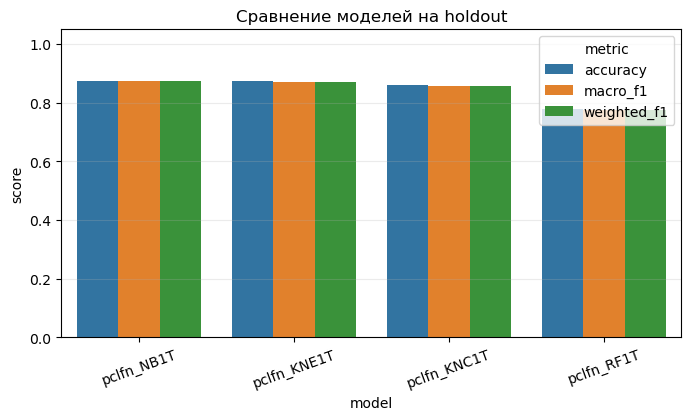

Лучшая модель: pclfn_NB1T

                       precision    recall  f1-score   support

         insomnia_now     0.9091    0.8333    0.8696        12
sleep_duration_report     1.0000    0.8333    0.9091        12
sleep_schedule_report     0.6667    1.0000    0.8000        12
              welcome     1.0000    1.0000    1.0000        12
                other     1.0000    0.5833    0.7368        12
              goodbye     0.8571    1.0000    0.9231        12

             accuracy                         0.8750        72
            macro avg     0.9055    0.8750    0.8731        72
         weighted avg     0.9055    0.8750    0.8731        72



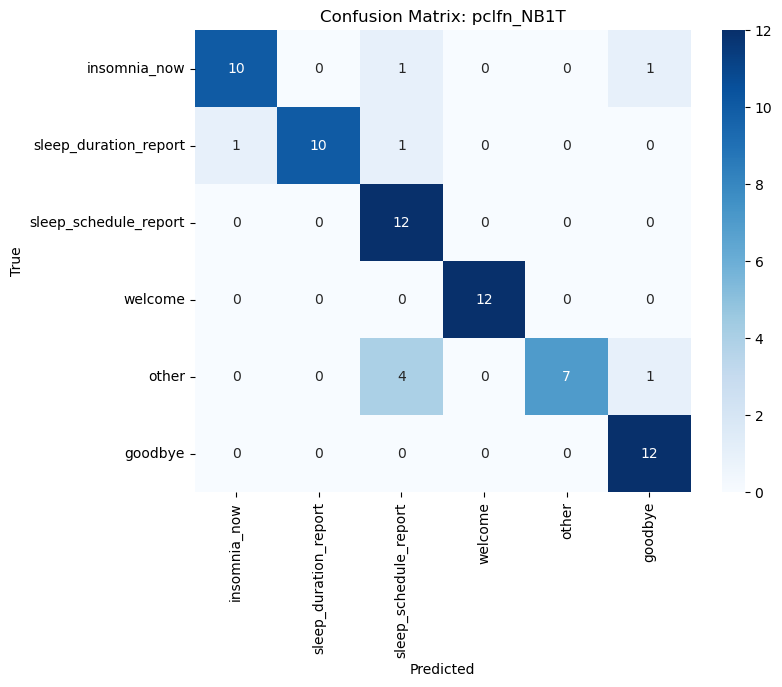

Ошибок: 9 из 72


,text,intent,pred_intent
0,"время позднее, а я все еще бодрствую",insomnia_now,goodbye
1,"в кровати уже давно, а сна нет совсем",insomnia_now,sleep_schedule_report
2,по трекеру получилось 5 часов 20 минут,sleep_duration_report,sleep_schedule_report
3,этой ночью проспал почти 9 часов,sleep_duration_report,insomnia_now
4,покажи погоду на сегодня,other,goodbye
5,переведи фразу good morning,other,sleep_schedule_report
6,расскажи короткую шутку,other,sleep_schedule_report
7,найди ближайшую аптеку,other,sleep_schedule_report
8,подскажи рецепт омлета,other,sleep_schedule_report


,intent,precision,recall,f1,support
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,0.8571,1.0000,0.9231,12
1,sleep_duration_report,1.0000,0.8333,0.9091,12
0,insomnia_now,0.9091,0.8333,0.8696,12
2,sleep_schedule_report,0.6667,1.0000,0.8000,12
4,other,1.0000,0.5833,0.7368,12


In [109]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "pclfn_NB1T": pclfn_NB1T,
    "pclfn_NB2T": pclfn_NB2T,
    "pclfn_NB3T": pclfn_NB3T,
    "pclfn_KNE1T": pclfn_KNE1T,
    "pclfn_KNE2T": pclfn_KNE2T,
    "pclfn_KNE3T": pclfn_KNE3T,
    "pclfn_KNC1T": pclfn_KNC1T,
    "pclfn_KNC2T": pclfn_KNC2T,
    "pclfn_KNC3T": pclfn_KNC3T,
    "pclfn_RF1T": pclfn_RF1T,
    "pclfn_RF2T": pclfn_RF2T,
    "pclfn_RF3T": pclfn_RF3T,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


,model,accuracy,macro_f1,weighted_f1
0,clf_NB1T,0.9722,0.9727,0.9727
1,clf_KNC1T,0.9583,0.9581,0.9581
2,clf_KNE1T,0.9167,0.9161,0.9161
3,clf_RF1T,0.8889,0.8856,0.8856
4,pclfn_NB1T,0.8750,0.8731,0.8731
5,pclfn_KNE1T,0.8750,0.8708,0.8708
6,pclfn_KNC1T,0.8611,0.8573,0.8573
7,pclfn_RF1T,0.7778,0.7749,0.7749
8,pclf_NB1T,0.6806,0.6582,0.6582
9,pclf_KNC1T,0.6667,0.6473,0.6473


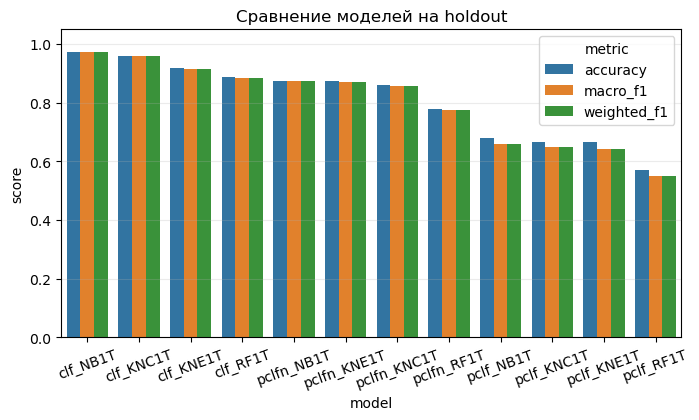

Лучшая модель: clf_NB1T

                       precision    recall  f1-score   support

         insomnia_now     1.0000    0.9167    0.9565        12
sleep_duration_report     1.0000    1.0000    1.0000        12
sleep_schedule_report     0.8571    1.0000    0.9231        12
              welcome     1.0000    1.0000    1.0000        12
                other     1.0000    0.9167    0.9565        12
              goodbye     1.0000    1.0000    1.0000        12

             accuracy                         0.9722        72
            macro avg     0.9762    0.9722    0.9727        72
         weighted avg     0.9762    0.9722    0.9727        72



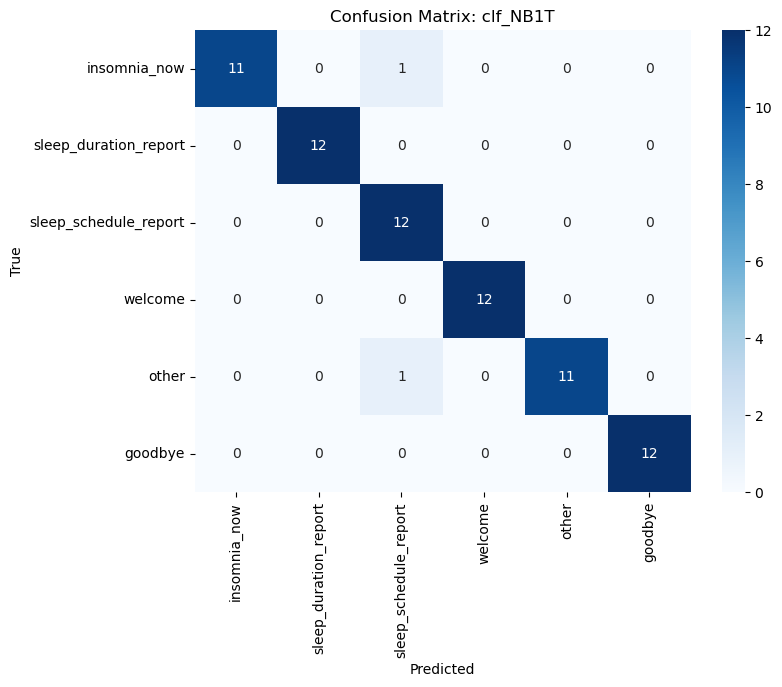

Ошибок: 2 из 72


,text,intent,pred_intent
0,проснулся среди ночи и больше не уснул,insomnia_now,sleep_schedule_report
1,подскажи рецепт омлета,other,sleep_schedule_report


,intent,precision,recall,f1,support
1,sleep_duration_report,1.0000,1.0000,1.0000,12
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,1.0000,1.0000,1.0000,12
0,insomnia_now,1.0000,0.9167,0.9565,12
4,other,1.0000,0.9167,0.9565,12
2,sleep_schedule_report,0.8571,1.0000,0.9231,12


In [113]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_NB1T": clf_NB1T,
    "clf_NB2T": clf_NB2T,
    "clf_NB3T": clf_NB3T,
    "clf_KNE1T": clf_KNE1T,
    "clf_KNE2T": clf_KNE2T,
    "clf_KNE3T": clf_KNE3T,
    "clf_KNC1T": clf_KNC1T,
    "clf_KNC2T": clf_KNC2T,
    "clf_KNC3T": clf_KNC3T,
    "clf_RF1T": clf_RF1T,
    "clf_RF2T": clf_RF2T,
    "clf_RF3T": clf_RF3T,
    
    "pclf_NB1T": pclf_NB1T,
    "pclf_NB2T": pclf_NB2T,
    "pclf_NB3T": pclf_NB3T,
    "pclf_KNE1T": pclf_KNE1T,
    "pclf_KNE2T": pclf_KNE2T,
    "pclf_KNE3T": pclf_KNE3T,
    "pclf_KNC1T": pclf_KNC1T,
    "pclf_KNC2T": pclf_KNC2T,
    "pclf_KNC3T": pclf_KNC3T,
    "pclf_RF1T": pclf_RF1T,
    "pclf_RF2T": pclf_RF2T,
    "pclf_RF3T": pclf_RF3T,
    
    "pclfn_NB1T": pclfn_NB1T,
    "pclfn_NB2T": pclfn_NB2T,
    "pclfn_NB3T": pclfn_NB3T,
    "pclfn_KNE1T": pclfn_KNE1T,
    "pclfn_KNE2T": pclfn_KNE2T,
    "pclfn_KNE3T": pclfn_KNE3T,
    "pclfn_KNC1T": pclfn_KNC1T,
    "pclfn_KNC2T": pclfn_KNC2T,
    "pclfn_KNC3T": pclfn_KNC3T,
    "pclfn_RF1T": pclfn_RF1T,
    "pclfn_RF2T": pclfn_RF2T,
    "pclfn_RF3T": pclfn_RF3T,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# ОБЩИЙ ВЫВОД О МОДЕЛЯМ МАШИННОГО ОБУЧЕНИЯ

,model,accuracy,macro_f1,weighted_f1
0,clf_NB2,0.9722,0.9727,0.9727
1,clf_NB3,0.9722,0.9727,0.9727
2,clf_NB1T,0.9722,0.9727,0.9727
3,clf_NB1,0.9583,0.9581,0.9581
4,clf_KNC1,0.9583,0.9581,0.9581
5,clf_KNC1T,0.9583,0.9581,0.9581
6,clf_KNC2,0.9444,0.9435,0.9435
7,clf_KNC3,0.9444,0.9435,0.9435
8,clf_RF1,0.9306,0.9289,0.9289
9,clf_KNE1T,0.9167,0.9161,0.9161


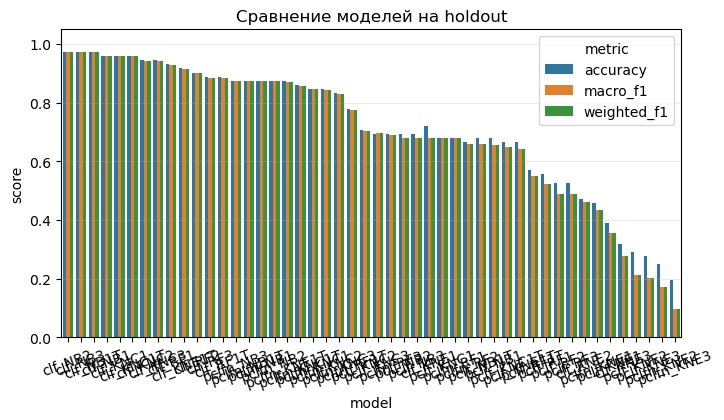

Лучшая модель: clf_NB2

                       precision    recall  f1-score   support

         insomnia_now     1.0000    0.9167    0.9565        12
sleep_duration_report     1.0000    1.0000    1.0000        12
sleep_schedule_report     0.8571    1.0000    0.9231        12
              welcome     1.0000    1.0000    1.0000        12
                other     1.0000    0.9167    0.9565        12
              goodbye     1.0000    1.0000    1.0000        12

             accuracy                         0.9722        72
            macro avg     0.9762    0.9722    0.9727        72
         weighted avg     0.9762    0.9722    0.9727        72



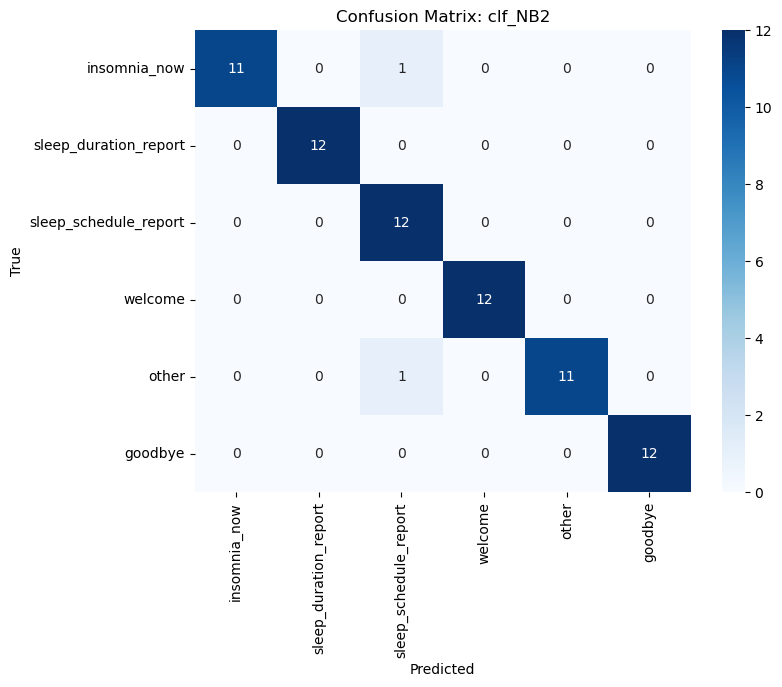

Ошибок: 2 из 72


,text,intent,pred_intent
0,проснулся среди ночи и больше не уснул,insomnia_now,sleep_schedule_report
1,подскажи рецепт омлета,other,sleep_schedule_report


,intent,precision,recall,f1,support
1,sleep_duration_report,1.0000,1.0000,1.0000,12
3,welcome,1.0000,1.0000,1.0000,12
5,goodbye,1.0000,1.0000,1.0000,12
0,insomnia_now,1.0000,0.9167,0.9565,12
4,other,1.0000,0.9167,0.9565,12
2,sleep_schedule_report,0.8571,1.0000,0.9231,12


In [114]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_NB1": clf_NB1,
    "clf_NB2": clf_NB2,
    "clf_NB3": clf_NB3,
    "clf_KNE1": clf_KNE1,
    "clf_KNE2": clf_KNE2,
    "clf_KNE3": clf_KNE3,
    "clf_KNC1": clf_KNC1,
    "clf_KNC2": clf_KNC2,
    "clf_KNC3": clf_KNC3,
    "clf_RF1": clf_RF1,
    "clf_RF2": clf_RF2,
    "clf_RF3": clf_RF3,
    "pclf_NB1": pclf_NB1,
    "pclf_NB2": pclf_NB2,
    "pclf_NB3": pclf_NB3,
    "pclf_KNE1": pclf_KNE1,
    "pclf_KNE2": pclf_KNE2,
    "pclf_KNE3": pclf_KNE3,
    "pclf_KNC1": pclf_KNC1,
    "pclf_KNC2": pclf_KNC2,
    "pclf_KNC3": pclf_KNC3,
    "pclf_RF1": pclf_RF1,
    "pclf_RF2": pclf_RF2,
    "pclf_RF3": pclf_RF3,
    "pclfn_NB1": pclfn_NB1,
    "pclfn_NB2": pclfn_NB2,
    "pclfn_NB3": pclfn_NB3,
    "pclfn_KNE1": pclfn_KNE1,
    "pclfn_KNE2": pclfn_KNE2,
    "pclfn_KNE3": pclfn_KNE3,
    "pclfn_KNC1": pclfn_KNC1,
    "pclfn_KNC2": pclfn_KNC2,
    "pclfn_KNC3": pclfn_KNC3,
    "pclfn_RF1": pclfn_RF1,
    "pclfn_RF2": pclfn_RF2,
    "pclfn_RF3": pclfn_RF3,
    
    "clf_NB1T": clf_NB1T,
    "clf_NB2T": clf_NB2T,
    "clf_NB3T": clf_NB3T,
    "clf_KNE1T": clf_KNE1T,
    "clf_KNE2T": clf_KNE2T,
    "clf_KNE3T": clf_KNE3T,
    "clf_KNC1T": clf_KNC1T,
    "clf_KNC2T": clf_KNC2T,
    "clf_KNC3T": clf_KNC3T,
    "clf_RF1T": clf_RF1T,
    "clf_RF2T": clf_RF2T,
    "clf_RF3T": clf_RF3T,
    "pclf_NB1T": pclf_NB1T,
    "pclf_NB2T": pclf_NB2T,
    "pclf_NB3T": pclf_NB3T,
    "pclf_KNE1T": pclf_KNE1T,
    "pclf_KNE2T": pclf_KNE2T,
    "pclf_KNE3T": pclf_KNE3T,
    "pclf_KNC1T": pclf_KNC1T,
    "pclf_KNC2T": pclf_KNC2T,
    "pclf_KNC3T": pclf_KNC3T,
    "pclf_RF1T": pclf_RF1T,
    "pclf_RF2T": pclf_RF2T,
    "pclf_RF3T": pclf_RF3T,
    "pclfn_NB1T": pclfn_NB1T,
    "pclfn_NB2T": pclfn_NB2T,
    "pclfn_NB3T": pclfn_NB3T,
    "pclfn_KNE1T": pclfn_KNE1T,
    "pclfn_KNE2T": pclfn_KNE2T,
    "pclfn_KNE3T": pclfn_KNE3T,
    "pclfn_KNC1T": pclfn_KNC1T,
    "pclfn_KNC2T": pclfn_KNC2T,
    "pclfn_KNC3T": pclfn_KNC3T,
    "pclfn_RF1T": pclfn_RF1T,
    "pclfn_RF2T": pclfn_RF2T,
    "pclfn_RF3T": pclfn_RF3T,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# МОДЕЛИ CatBoost и GradientBoosting без preprocess через CountVectorizer

In [ ]:
from catboost import Pool, CatBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.text, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [ ]:
clf_GB1 = Pipeline([
    ("tfidf", CountVectorizer()),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
clf_GB1.fit(X_train, y_train)
y_pred = clf_GB1.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
clf_GB2 = Pipeline([
    ("tfidf", CountVectorizer(ngram_range=(1, 2))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
clf_GB2.fit(X_train, y_train)
y_pred = clf_GB2.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
clf_GB3 = Pipeline([
    ("tfidf", CountVectorizer(ngram_range=(1, 3))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
clf_GB3.fit(X_train, y_train)
y_pred = clf_GB3.predict(X_test)
print(classification_report(y_test, y_pred))

# МОДЕЛИ CatBoost и GradientBoosting c preprocess через CountVectorizer

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocess, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [ ]:
pclf_GB1 = Pipeline([
    ("tfidf", CountVectorizer()),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclf_GB1.fit(X_train, y_train)
y_pred = pclf_GB1.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclf_GB2 = Pipeline([
    ("tfidf", CountVectorizer(ngram_range=(1, 2))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclf_GB2.fit(X_train, y_train)
y_pred = pclf_GB2.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclf_GB3 = Pipeline([
    ("tfidf", CountVectorizer(ngram_range=(1, 3))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclf_GB3.fit(X_train, y_train)
y_pred = pclf_GB3.predict(X_test)
print(classification_report(y_test, y_pred))

# МОДЕЛИ CatBoost и GradientBoosting c preprocess_new через CountVectorizer

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocess_new, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [ ]:
pclfn_GB1 = Pipeline([
    ("tfidf", CountVectorizer()),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclfn_GB1.fit(X_train, y_train)
y_pred = pclfn_GB1.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclfn_GB2 = Pipeline([
    ("tfidf", CountVectorizer(ngram_range=(1, 2))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclfn_GB2.fit(X_train, y_train)
y_pred = pclfn_GB2.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclfn_GB3 = Pipeline([
    ("tfidf", CountVectorizer(ngram_range=(1, 3))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclfn_GB3.fit(X_train, y_train)
y_pred = pclfn_GB3.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_GB1": clf_GB1,
    "clf_GB2": clf_GB2,
    "clf_GB3": clf_GB3,
    "pclf_GB1": pclf_GB1,
    "pclf_GB2": pclf_GB2,
    "pclf_GB3": pclf_GB3,
    "pclfn_GB1": pclfn_GB1,
    "pclfn_GB2": pclfn_GB2,
    "pclfn_GB3": pclfn_GB3,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# МОДЕЛИ CatBoost и GradientBoosting без preprocess через TfidVectorizer

In [121]:
from catboost import Pool, CatBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.text, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [125]:
clf_GB1T = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
clf_GB1T.fit(X_train, y_train)
y_pred = clf_GB1T.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [ ]:
clf_GB2T = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
clf_GB2T.fit(X_train, y_train)
y_pred = clf_GB2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
clf_GB3T = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 3))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
clf_GB3T.fit(X_train, y_train)
y_pred = clf_GB3T.predict(X_test)
print(classification_report(y_test, y_pred))

In [126]:
X_train_df = pd.DataFrame({"text": X_train.values})
X_test_df = pd.DataFrame({"text": X_test.values})

train_pool = Pool(
    data=X_train_df,
    label=y_train,
    text_features=["text"],
)
test_pool = Pool(
    data=X_test_df,
    label=y_test,
    text_features=["text"],
)

0:	learn: 1.6727479	test: 1.6652626	best: 1.6652626 (0)	total: 20.4ms	remaining: 16.3s
100:	learn: 0.2221275	test: 0.1424966	best: 0.1424966 (100)	total: 2.59s	remaining: 17.9s
200:	learn: 0.1659244	test: 0.0995021	best: 0.0995021 (200)	total: 5.18s	remaining: 15.4s
300:	learn: 0.1400314	test: 0.0823330	best: 0.0823330 (300)	total: 7.78s	remaining: 12.9s
400:	learn: 0.1204314	test: 0.0694405	best: 0.0694405 (400)	total: 10.4s	remaining: 10.4s
500:	learn: 0.1086423	test: 0.0636471	best: 0.0635633 (498)	total: 13s	remaining: 7.75s
600:	learn: 0.0987356	test: 0.0594494	best: 0.0594275 (599)	total: 15.7s	remaining: 5.19s
700:	learn: 0.0900375	test: 0.0560153	best: 0.0560153 (700)	total: 18.4s	remaining: 2.59s
799:	learn: 0.0830943	test: 0.0540765	best: 0.0540732 (798)	total: 21s	remaining: 0us

bestTest = 0.05407319978
bestIteration = 798

Shrink model to first 799 iterations.
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
     

In [ ]:
clf_CB = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=800,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=8,
    random_seed=2022,
    verbose=100,
    # для русского текста часто помогает:
    tokenizers=[{"tokenizer_id": "Space", "separator_type": "ByDelimiter"}],
)

clf_CB.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    early_stopping_rounds=80,
)

y_pred = clf_CB.predict(test_pool).astype(int).ravel()
print(classification_report(y_test, y_pred))

# МОДЕЛИ CatBoost и GradientBoosting c preprocess

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocess, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [ ]:
pclf_GB1T = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclf_GB1T.fit(X_train, y_train)
y_pred = pclf_GB1T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclf_GB2T = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclf_GB2T.fit(X_train, y_train)
y_pred = pclf_GB2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclf_GB3T = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 3))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclf_GB3T.fit(X_train, y_train)
y_pred = pclf_GB3T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
X_train_df = pd.DataFrame({"preprocess": X_train.values})
X_test_df = pd.DataFrame({"preprocess": X_test.values})

train_pool = Pool(
    data=X_train_df,
    label=y_train,
    text_features=["preprocess"],
)
test_pool = Pool(
    data=X_test_df,
    label=y_test,
    text_features=["preprocess"],
)

In [ ]:
pclf_CB = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=800,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=8,
    random_seed=2022,
    verbose=100,
    # для русского текста часто помогает:
    tokenizers=[{"tokenizer_id": "Space", "separator_type": "ByDelimiter"}],
)

pclf_CB.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    early_stopping_rounds=80,
)

y_pred = pclf_CB.predict(test_pool).astype(int).ravel()
print(classification_report(y_test, y_pred))

# МОДЕЛИ CatBoost и GradientBoosting c new_preprocess

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocess_new, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [ ]:
pclfn_GB1T = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclfn_GB1T.fit(X_train, y_train)
y_pred = pclfn_GB1T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclfn_GB2T = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclfn_GB2T.fit(X_train, y_train)
y_pred = pclfn_GB2T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
pclfn_GB3T = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 3))),
    ("gb", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=2022,
    )),
])
pclfn_GB3T.fit(X_train, y_train)
y_pred = pclfn_GB3T.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
X_train_df = pd.DataFrame({"preprocess_new": X_train.values})
X_test_df = pd.DataFrame({"preprocess_new": X_test.values})

train_pool = Pool(
    data=X_train_df,
    label=y_train,
    text_features=["preprocess_new"],
)
test_pool = Pool(
    data=X_test_df,
    label=y_test,
    text_features=["preprocess_new"],
)

In [ ]:
pclfn_CB = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=800,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=8,
    random_seed=2022,
    verbose=100,
    # для русского текста часто помогает:
    tokenizers=[{"tokenizer_id": "Space", "separator_type": "ByDelimiter"}],
)

pclfn_CB.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    early_stopping_rounds=80,
)

y_pred = pclfn_CB.predict(test_pool).astype(int).ravel()
print(classification_report(y_test, y_pred))

In [ ]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_GB1T": clf_GB1T,
    "clf_GB2T": clf_GB2T,
    "clf_GB3T": clf_GB3T,
    "clf_CB": clf_CB,
    "pclf_GB1T": pclf_GB1T,
    "pclf_GB2T": pclf_GB2T,
    "pclf_GB3T": pclf_GB3T,
    "pclf_CB": pclf_CB,
    "pclfn_GB1T": pclfn_GB1T,
    "pclfn_GB2T": pclfn_GB2T,
    "pclfn_GB3T": pclfn_GB3T,
    "pclfn_CB": pclfn_CB,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


In [ ]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_GB1": clf_GB1,
    "clf_GB2": clf_GB2,
    "clf_GB3": clf_GB3,
    "pclf_GB1": pclf_GB1,
    "pclf_GB2": pclf_GB2,
    "pclf_GB3": pclf_GB3,
    "pclfn_GB1": pclfn_GB1,
    "pclfn_GB2": pclfn_GB2,
    "pclfn_GB3": pclfn_GB3,
    
    "clf_GB1T": clf_GB1T,
    "clf_GB2T": clf_GB2T,
    "clf_GB3T": clf_GB3T,
    "clf_CB": clf_CB,
    "pclf_GB1T": pclf_GB1T,
    "pclf_GB2T": pclf_GB2T,
    "pclf_GB3T": pclf_GB3T,
    "pclf_CB": pclf_CB,
    "pclfn_GB1T": pclfn_GB1T,
    "pclfn_GB2T": pclfn_GB2T,
    "pclfn_GB3T": pclfn_GB3T,
    "pclfn_CB": pclfn_CB,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


In [ ]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_NB1": clf_NB1,
    "clf_NB2": clf_NB2,
    "clf_NB3": clf_NB3,
    "clf_KNE1": clf_KNE1,
    "clf_KNE2": clf_KNE2,
    "clf_KNE3": clf_KNE3,
    "clf_KNC1": clf_KNC1,
    "clf_KNC2": clf_KNC2,
    "clf_KNC3": clf_KNC3,
    "clf_RF1": clf_RF1,
    "clf_RF2": clf_RF2,
    "clf_RF3": clf_RF3,
    "pclf_NB1": pclf_NB1,
    "pclf_NB2": pclf_NB2,
    "pclf_NB3": pclf_NB3,
    "pclf_KNE1": pclf_KNE1,
    "pclf_KNE2": pclf_KNE2,
    "pclf_KNE3": pclf_KNE3,
    "pclf_KNC1": pclf_KNC1,
    "pclf_KNC2": pclf_KNC2,
    "pclf_KNC3": pclf_KNC3,
    "pclf_RF1": pclf_RF1,
    "pclf_RF2": pclf_RF2,
    "pclf_RF3": pclf_RF3,
    "pclfn_NB1": pclfn_NB1,
    "pclfn_NB2": pclfn_NB2,
    "pclfn_NB3": pclfn_NB3,
    "pclfn_KNE1": pclfn_KNE1,
    "pclfn_KNE2": pclfn_KNE2,
    "pclfn_KNE3": pclfn_KNE3,
    "pclfn_KNC1": pclfn_KNC1,
    "pclfn_KNC2": pclfn_KNC2,
    "pclfn_KNC3": pclfn_KNC3,
    "pclfn_RF1": pclfn_RF1,
    "pclfn_RF2": pclfn_RF2,
    "pclfn_RF3": pclfn_RF3,
    
    "clf_NB1T": clf_NB1T,
    "clf_NB2T": clf_NB2T,
    "clf_NB3T": clf_NB3T,
    "clf_KNE1T": clf_KNE1T,
    "clf_KNE2T": clf_KNE2T,
    "clf_KNE3T": clf_KNE3T,
    "clf_KNC1T": clf_KNC1T,
    "clf_KNC2T": clf_KNC2T,
    "clf_KNC3T": clf_KNC3T,
    "clf_RF1T": clf_RF1T,
    "clf_RF2T": clf_RF2T,
    "clf_RF3T": clf_RF3T,
    "pclf_NB1T": pclf_NB1T,
    "pclf_NB2T": pclf_NB2T,
    "pclf_NB3T": pclf_NB3T,
    "pclf_KNE1T": pclf_KNE1T,
    "pclf_KNE2T": pclf_KNE2T,
    "pclf_KNE3T": pclf_KNE3T,
    "pclf_KNC1T": pclf_KNC1T,
    "pclf_KNC2T": pclf_KNC2T,
    "pclf_KNC3T": pclf_KNC3T,
    "pclf_RF1T": pclf_RF1T,
    "pclf_RF2T": pclf_RF2T,
    "pclf_RF3T": pclf_RF3T,
    "pclfn_NB1T": pclfn_NB1T,
    "pclfn_NB2T": pclfn_NB2T,
    "pclfn_NB3T": pclfn_NB3T,
    "pclfn_KNE1T": pclfn_KNE1T,
    "pclfn_KNE2T": pclfn_KNE2T,
    "pclfn_KNE3T": pclfn_KNE3T,
    "pclfn_KNC1T": pclfn_KNC1T,
    "pclfn_KNC2T": pclfn_KNC2T,
    "pclfn_KNC3T": pclfn_KNC3T,
    "pclfn_RF1T": pclfn_RF1T,
    "pclfn_RF2T": pclfn_RF2T,
    "pclfn_RF3T": pclfn_RF3T,

    "clf_GB1": clf_GB1,
    "clf_GB2": clf_GB2,
    "clf_GB3": clf_GB3,
    "pclf_GB1": pclf_GB1,
    "pclf_GB2": pclf_GB2,
    "pclf_GB3": pclf_GB3,
    "pclfn_GB1": pclfn_GB1,
    "pclfn_GB2": pclfn_GB2,
    "pclfn_GB3": pclfn_GB3,
    
    "clf_GB1T": clf_GB1T,
    "clf_GB2T": clf_GB2T,
    "clf_GB3T": clf_GB3T,
    "clf_CB": clf_CB,
    "pclf_GB1T": pclf_GB1T,
    "pclf_GB2T": pclf_GB2T,
    "pclf_GB3T": pclf_GB3T,
    "pclf_CB": pclf_CB,
    "pclfn_GB1T": pclfn_GB1T,
    "pclfn_GB2T": pclfn_GB2T,
    "pclfn_GB3T": pclfn_GB3T,
    "pclfn_CB": pclfn_CB,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


# Через spaCy(без bag-of-words) без preprocess

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.text, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [ ]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

def texts_to_doc_vectors(texts, nlp, batch_size=64):
    vectors = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        vectors.append(doc.vector)
    return np.vstack(vectors)

X_train_vec = texts_to_doc_vectors(X_train, nlp)
X_test_vec = texts_to_doc_vectors(X_test, nlp)


In [ ]:
clf_GBS = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=2022,
)
clf_GBS.fit(X_train_vec, y_train)
y_pred = clf_GBS.predict(X_test_vec)
print(classification_report(y_test, y_pred))

clf_CBS = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=800,
    learning_rate=0.05,
    depth=4,
    random_seed=2022,
    verbose=100,
)
clf_CBS.fit(X_train_vec, y_train, eval_set=(X_test_vec, y_test), use_best_model=True)
y_pred = clf_CBS.predict(X_test_vec).astype(int).ravel()
print(classification_report(y_test, y_pred))

# Через spaCy(без bag-of-words) c preprocess

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocess, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [ ]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

def texts_to_doc_vectors(texts, nlp, batch_size=64):
    vectors = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        vectors.append(doc.vector)
    return np.vstack(vectors)

X_train_vec = texts_to_doc_vectors(X_train, nlp)
X_test_vec = texts_to_doc_vectors(X_test, nlp)


In [ ]:
pclf_GBS = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=2022,
)
pclf_GBS.fit(X_train_vec, y_train)
y_pred = pclf_GBS.predict(X_test_vec)
print(classification_report(y_test, y_pred))

pclf_CBS = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=800,
    learning_rate=0.05,
    depth=4,
    random_seed=2022,
    verbose=100,
)
pclf_CBS.fit(X_train_vec, y_train, eval_set=(X_test_vec, y_test), use_best_model=True)
y_pred = pclf_CBS.predict(X_test_vec).astype(int).ravel()
print(classification_report(y_test, y_pred))

# Через spaCy(без bag-of-words) c preprocess_new

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocess_new, 
    df.intent_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.intent_num
)

In [ ]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

def texts_to_doc_vectors(texts, nlp, batch_size=64):
    vectors = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        vectors.append(doc.vector)
    return np.vstack(vectors)

X_train_vec = texts_to_doc_vectors(X_train, nlp)
X_test_vec = texts_to_doc_vectors(X_test, nlp)


In [ ]:
pclfn_GBS = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=2022,
)
pclfn_GBS.fit(X_train_vec, y_train)
y_pred = pclfn_GBS.predict(X_test_vec)
print(classification_report(y_test, y_pred))

pclfn_CBS = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=800,
    learning_rate=0.05,
    depth=4,
    random_seed=2022,
    verbose=100,
)
pclfn_CBS.fit(X_train_vec, y_train, eval_set=(X_test_vec, y_test), use_best_model=True)
y_pred = pclfn_CBS.predict(X_test_vec).astype(int).ravel()
print(classification_report(y_test, y_pred))

In [ ]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_GBS": clf_GBS,
    "clf_CBS": clf_CBS,
    "pclf_GBS": pclf_GBS,
    "pclf_CBS": pclf_CBS,    
    "pclfn_GBS": pclfn_GBS,
    "pclfn_CBS": pclfn_CBS,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


In [ ]:
# 1) Пути и данные
HOLDOUT_PATH = "sleep_intents_holdout.csv"   # твой проверочный датасет
holdout_df = pd.read_csv(HOLDOUT_PATH)
# target должен уже существовать из твоего кода:
# target = {'insomnia_now': 0, 'sleep_duration_report': 1, ...}
inv_target = {v: k for k, v in target.items()}
holdout_df["intent_num"] = holdout_df["intent"].map(target)
if holdout_df["intent_num"].isna().any():
    bad = holdout_df[holdout_df["intent_num"].isna()]["intent"].unique()
    raise ValueError(f"В holdout есть интенты вне target: {bad}")
X_holdout = holdout_df["text"]
y_holdout = holdout_df["intent_num"]
# 2) Собираем модели для сравнения
# Минимум: текущая clf
# Если в ноутбуке есть еще обученные модели - добавь сюда
models = {
    "clf_NB1": clf_NB1,
    "clf_NB2": clf_NB2,
    "clf_NB3": clf_NB3,
    "clf_KNE1": clf_KNE1,
    "clf_KNE2": clf_KNE2,
    "clf_KNE3": clf_KNE3,
    "clf_KNC1": clf_KNC1,
    "clf_KNC2": clf_KNC2,
    "clf_KNC3": clf_KNC3,
    "clf_RF1": clf_RF1,
    "clf_RF2": clf_RF2,
    "clf_RF3": clf_RF3,
    "pclf_NB1": pclf_NB1,
    "pclf_NB2": pclf_NB2,
    "pclf_NB3": pclf_NB3,
    "pclf_KNE1": pclf_KNE1,
    "pclf_KNE2": pclf_KNE2,
    "pclf_KNE3": pclf_KNE3,
    "pclf_KNC1": pclf_KNC1,
    "pclf_KNC2": pclf_KNC2,
    "pclf_KNC3": pclf_KNC3,
    "pclf_RF1": pclf_RF1,
    "pclf_RF2": pclf_RF2,
    "pclf_RF3": pclf_RF3,
    "pclfn_NB1": pclfn_NB1,
    "pclfn_NB2": pclfn_NB2,
    "pclfn_NB3": pclfn_NB3,
    "pclfn_KNE1": pclfn_KNE1,
    "pclfn_KNE2": pclfn_KNE2,
    "pclfn_KNE3": pclfn_KNE3,
    "pclfn_KNC1": pclfn_KNC1,
    "pclfn_KNC2": pclfn_KNC2,
    "pclfn_KNC3": pclfn_KNC3,
    "pclfn_RF1": pclfn_RF1,
    "pclfn_RF2": pclfn_RF2,
    "pclfn_RF3": pclfn_RF3,
    
    "clf_NB1T": clf_NB1T,
    "clf_NB2T": clf_NB2T,
    "clf_NB3T": clf_NB3T,
    "clf_KNE1T": clf_KNE1T,
    "clf_KNE2T": clf_KNE2T,
    "clf_KNE3T": clf_KNE3T,
    "clf_KNC1T": clf_KNC1T,
    "clf_KNC2T": clf_KNC2T,
    "clf_KNC3T": clf_KNC3T,
    "clf_RF1T": clf_RF1T,
    "clf_RF2T": clf_RF2T,
    "clf_RF3T": clf_RF3T,
    "pclf_NB1T": pclf_NB1T,
    "pclf_NB2T": pclf_NB2T,
    "pclf_NB3T": pclf_NB3T,
    "pclf_KNE1T": pclf_KNE1T,
    "pclf_KNE2T": pclf_KNE2T,
    "pclf_KNE3T": pclf_KNE3T,
    "pclf_KNC1T": pclf_KNC1T,
    "pclf_KNC2T": pclf_KNC2T,
    "pclf_KNC3T": pclf_KNC3T,
    "pclf_RF1T": pclf_RF1T,
    "pclf_RF2T": pclf_RF2T,
    "pclf_RF3T": pclf_RF3T,
    "pclfn_NB1T": pclfn_NB1T,
    "pclfn_NB2T": pclfn_NB2T,
    "pclfn_NB3T": pclfn_NB3T,
    "pclfn_KNE1T": pclfn_KNE1T,
    "pclfn_KNE2T": pclfn_KNE2T,
    "pclfn_KNE3T": pclfn_KNE3T,
    "pclfn_KNC1T": pclfn_KNC1T,
    "pclfn_KNC2T": pclfn_KNC2T,
    "pclfn_KNC3T": pclfn_KNC3T,
    "pclfn_RF1T": pclfn_RF1T,
    "pclfn_RF2T": pclfn_RF2T,
    "pclfn_RF3T": pclfn_RF3T,

    "clf_GB1": clf_GB1,
    "clf_GB2": clf_GB2,
    "clf_GB3": clf_GB3,
    "pclf_GB1": pclf_GB1,
    "pclf_GB2": pclf_GB2,
    "pclf_GB3": pclf_GB3,
    "pclfn_GB1": pclfn_GB1,
    "pclfn_GB2": pclfn_GB2,
    "pclfn_GB3": pclfn_GB3,
    
    "clf_GB1T": clf_GB1T,
    "clf_GB2T": clf_GB2T,
    "clf_GB3T": clf_GB3T,
    "clf_CB": clf_CB,
    "pclf_GB1T": pclf_GB1T,
    "pclf_GB2T": pclf_GB2T,
    "pclf_GB3T": pclf_GB3T,
    "pclf_CB": pclf_CB,
    "pclfn_GB1T": pclfn_GB1T,
    "pclfn_GB2T": pclfn_GB2T,
    "pclfn_GB3T": pclfn_GB3T,
    "pclfn_CB": pclfn_CB,

    "clf_GBS": clf_GBS,
    "clf_CBS": clf_CBS,
    "pclf_GBS": pclf_GBS,
    "pclf_CBS": pclf_CBS,    
    "pclfn_GBS": pclfn_GBS,
    "pclfn_CBS": pclfn_CBS,
}
# 3) Считаем метрики по всем моделям
summary_rows = []
pred_store = {}
for name, model in models.items():
    y_pred = model.predict(X_holdout)
    pred_store[name] = y_pred
    
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_holdout, y_pred),
        "macro_f1": f1_score(y_holdout, y_pred, average="macro"),
        "weighted_f1": f1_score(y_holdout, y_pred, average="weighted"),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)
display(summary_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))
# 4) График сравнения моделей
plt.figure(figsize=(8, 4))
plot_df = summary_df.melt(id_vars="model", value_vars=["accuracy", "macro_f1", "weighted_f1"],
                          var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Сравнение моделей на holdout")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()
# 5) Подробный отчет для лучшей модели
best_model_name = summary_df.loc[0, "model"]
best_pred = pred_store[best_model_name]
print(f"Лучшая модель: {best_model_name}\n")
print(classification_report(
    y_holdout,
    best_pred,
    target_names=[inv_target[i] for i in sorted(inv_target.keys())],
    digits=4
))
# 6) Confusion matrix (лучшая модель)
cm = confusion_matrix(y_holdout, best_pred, labels=sorted(inv_target.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[inv_target[i] for i in sorted(inv_target.keys())],
    columns=[inv_target[i] for i in sorted(inv_target.keys())]
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# 7) Таблица ошибок (где модель ошиблась)
res_df = holdout_df.copy()
res_df["pred_num"] = best_pred
res_df["pred_intent"] = res_df["pred_num"].map(inv_target)
res_df["is_correct"] = res_df["pred_num"] == res_df["intent_num"]
errors_df = res_df[~res_df["is_correct"]][["text", "intent", "pred_intent"]].reset_index(drop=True)
print(f"Ошибок: {len(errors_df)} из {len(res_df)}")
display(errors_df.head(30))
# 8) Пер-класс метрики в табличке (лучшая модель)
p, r, f1, support = precision_recall_fscore_support(
    y_holdout, best_pred, labels=sorted(inv_target.keys()), zero_division=0
)
per_class_df = pd.DataFrame({
    "intent": [inv_target[i] for i in sorted(inv_target.keys())],
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": support
}).sort_values("f1", ascending=False)
display(per_class_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))
